<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/Random_Forest_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

In [8]:
train_files = [
    "channe14_LOS_cluster1.npy",
    "channe14_LOS_cluster2.npy",
    "channe14_NLOS_cluster1.npy",
    "channe14_NLOS_cluster2.npy",
    "channe14_NLOS_cluster3.npy"
]

test_files = [
    "channe14_LOS_cluster3.npy",
    "channe14_LOS_cluster4.npy",
    "channe14_NLOS_cluster4.npy",
    "channe14_NLOS_cluster5.npy"
]

In [9]:
import os
import numpy as np

X_train_list = []
y_train_list = []

for file in train_files:
    data = np.load(os.path.join(PROCESSED_DIR, file), allow_pickle=True)

    X_train_list.append(data)

    # Label (adjust based on filename)
    label = 0 if "NLOS" in file else 1
    y_train_list.append(np.full(data.shape[0], label))

# Combine
X_train = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)

print("Train shape:", X_train.shape)

Train shape: (30492, 72)


In [10]:
X_test_list = []
y_test_list = []

for file in test_files:
    data = np.load(os.path.join(PROCESSED_DIR, file), allow_pickle=True)

    X_test_list.append(data)

    label = 0 if "NLOS" in file else 1
    y_test_list.append(np.full(data.shape[0], label))

# Combine
X_test = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

print("Test shape:", X_test.shape)

Test shape: (24333, 72)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)

Test Accuracy: 0.5382402498664365


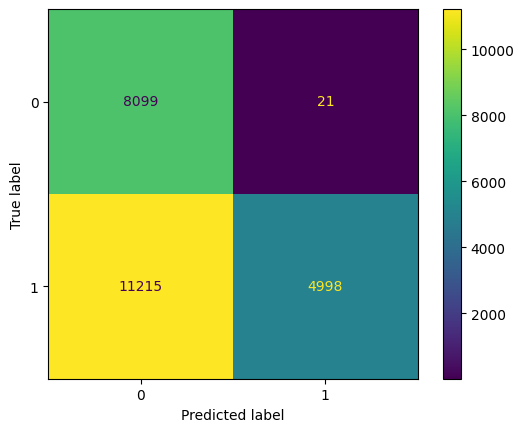

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [15]:
# Compute variance using ONLY training data
var_vals = np.var(X_train, axis=0)

# Get top 10 feature indices
top10_var_idx = np.argsort(var_vals)[-10:][::-1]

print("Top 10 features (from TRAIN):", top10_var_idx)

Top 10 features (from TRAIN): [11  6 56  5  7 15 10  3  8 16]


In [16]:
for idx in top10_var_idx:
    print(f"Feature {idx} → Variance: {var_vals[idx]:.4f}")

Feature 11 → Variance: 0.7404
Feature 6 → Variance: 0.6996
Feature 56 → Variance: 0.6369
Feature 5 → Variance: 0.6059
Feature 7 → Variance: 0.5827
Feature 15 → Variance: 0.5796
Feature 10 → Variance: 0.5712
Feature 3 → Variance: 0.5424
Feature 8 → Variance: 0.5168
Feature 16 → Variance: 0.5075


In [17]:
# Select top features
X_train_reduced = X_train[:, top10_var_idx]
X_test_reduced  = X_test[:, top10_var_idx]

print("Reduced train shape:", X_train_reduced.shape)
print("Reduced test shape:", X_test_reduced.shape)

Reduced train shape: (30492, 10)
Reduced test shape: (24333, 10)


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train_reduced, y_train)

y_pred = model.predict(X_test_reduced)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy (Top Features):", acc)

Test Accuracy (Top Features): 0.5102946615707065


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc

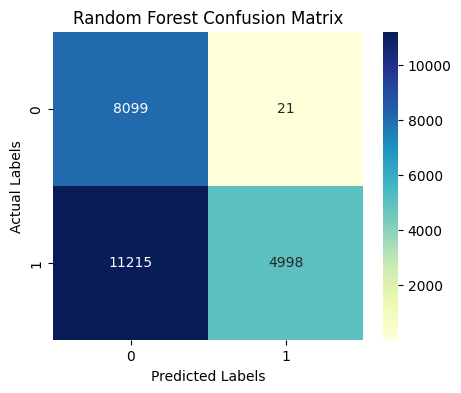

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["0", "1"],
            yticklabels=["0", "1"])

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [24]:
y_prob = model.predict_proba(X_test)[:, 1]

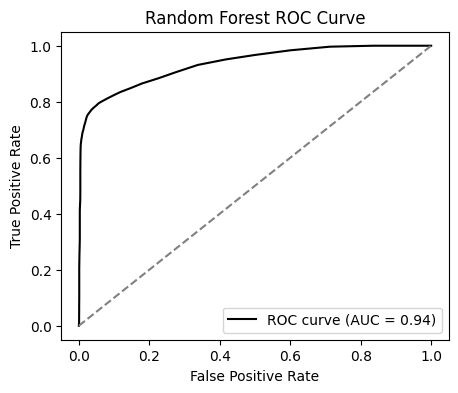

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))

plt.plot(fpr, tpr, color='black', label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()